In [1]:
import sys, os
import pandas as pd
import numpy as np

sys.path.append("..")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

DATA_PATH = os.path.join("..", "data", "raw", "mental-heath-in-tech-2016_20161114.csv")
df = pd.read_csv(DATA_PATH)

In [2]:
from src import feature_config
from src.preprocessing import (
    run_pipeline, prepare_for_feature_selection,
    impute_structural_missingness, fill_remaining_with_mean,
)
from src.feature_selection import (
    apply_chi_square, apply_mutual_information,
    apply_variance_threshold, apply_correlation_filter,
)

df_processed = run_pipeline(df, feature_config)

df_imputed = impute_structural_missingness(df_processed, feature_config.STRUCTURAL_MISSINGNESS)
df_imputed = fill_remaining_with_mean(df_imputed, exclude_cols=["age_group"])

print("Shape after pipeline + imputation:", df_imputed.shape)

negative_impact_reveal: 75 rows answered despite reveal_to_clients_direction==2
negative_impact_reveal_coworker: 30 rows answered despite reveal_to_coworkers_direction==2
percentage_affected: 38 rows answered despite productivity_affected==1
Shape after pipeline + imputation: (1433, 183)


In [3]:
df_selection_ready = prepare_for_feature_selection(df, feature_config)

chi_square_results = apply_chi_square(df_selection_ready, feature_config.FEATURE_FILTER_GROUPS)
mi_results = apply_mutual_information(df_selection_ready, feature_config.FEATURE_FILTER_GROUPS)

In [4]:
variance_threshold_results = apply_variance_threshold(df_imputed)
corr_matrix, high_corr_features = apply_correlation_filter(df_imputed, threshold=0.7)

In [5]:
columns_to_drop_variance = variance_threshold_results.loc[
    variance_threshold_results["kept"] == False, "feature"
].tolist()
columns_to_drop_variance.remove("reveal_to_clients_direction")  # override: imputation artifact, see DECISIONS.md

condition_dupes_to_drop = [
    "diagnosed_conditions__attention_deficit_hyperactivity_disorder",
    "diagnosed_conditions__obsessive_compulsive_disorder",
    "diagnosed_conditions__autism",
    "diagnosed_conditions__anxiety_disorder",
    "diagnosed_conditions__psychotic_disorder",
    "diagnosed_conditions__mood_disorder",
    "diagnosed_conditions__burn_out",
]

columns_to_drop = (
    columns_to_drop_variance
    + ["gender_cleaned_female"]
    + condition_dupes_to_drop
    + ["age_group"]
)

In [6]:
df_final = df_imputed.drop(columns=columns_to_drop, errors="ignore")

print("Shape before drop:", df_imputed.shape)
print("Shape after drop:", df_final.shape)
print("Remaining NaN:", df_final.isnull().sum().sum())

non_numeric = df_final.dtypes[~df_final.dtypes.apply(pd.api.types.is_numeric_dtype)]
print("Non-numeric columns:", list(non_numeric.index))

Shape before drop: (1433, 183)
Shape after drop: (1433, 151)
Remaining NaN: 0
Non-numeric columns: []


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_final)
X_scaled_df = pd.DataFrame(X_scaled, columns=df_final.columns, index=df_final.index)
X_scaled_df.shape

(1433, 151)

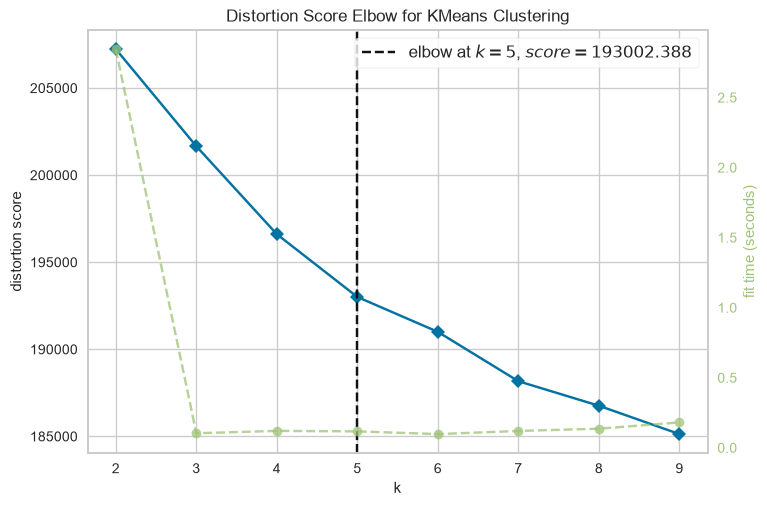

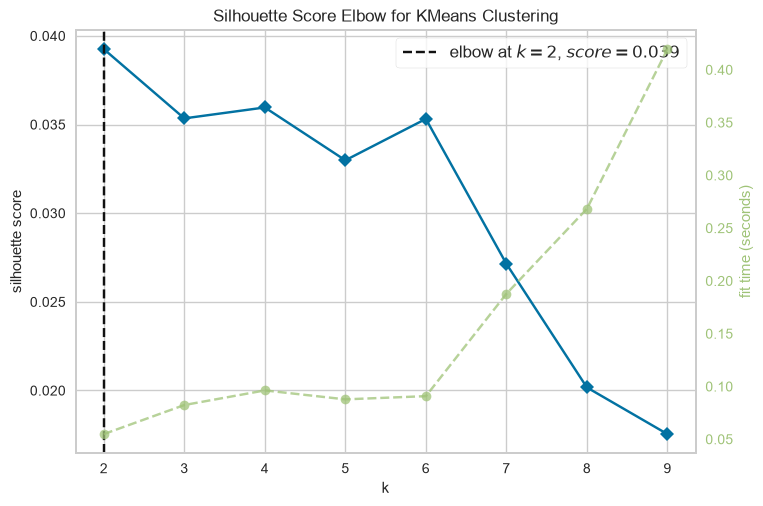

Elbow (distortion) suggests k = 5
Elbow (silhouette) suggests k = 2


In [8]:
from src.clustering import plot_elbow_method

viz_distortion = plot_elbow_method(X_scaled_df, max_k=10, metric='distortion')
viz_silhouette = plot_elbow_method(X_scaled_df, max_k=10, metric='silhouette')

print("Elbow (distortion) suggests k =", viz_distortion.elbow_value_)
print("Elbow (silhouette) suggests k =", viz_silhouette.elbow_value_)

Employed subgroup: n=1146
Self-employed subgroup excluded from clustering (n=287, too small for reliable segmentation)
PCA dims: 81 (from 150 original features)


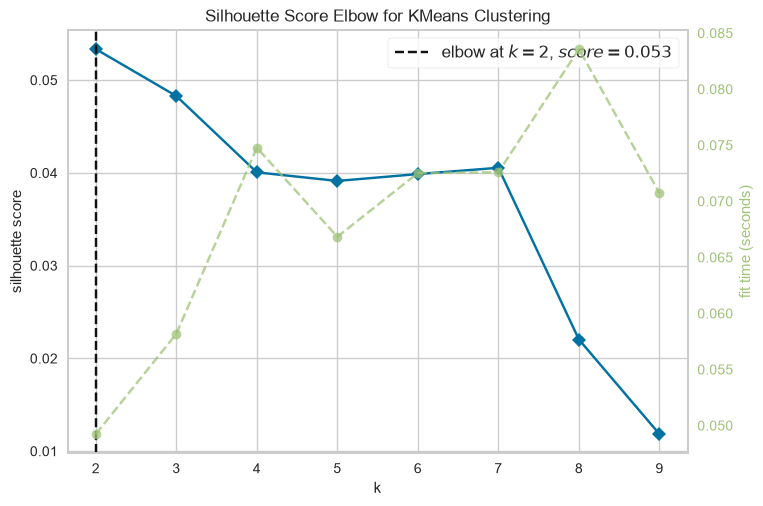

Elbow (PCA silhouette) suggests k = 2


In [9]:
from sklearn.decomposition import PCA

df_employed = df_final[df_final['self_employed'] == 0].copy()
print(f"Employed subgroup: n={len(df_employed)}")
print(f"Self-employed subgroup excluded from clustering (n={len(df_final) - len(df_employed)}, too small for reliable segmentation)")

X_employed = df_employed.drop(columns=['self_employed'])
X_employed_scaled = StandardScaler().fit_transform(X_employed)

pca = PCA(n_components=0.85, random_state=42)
X_pca = pca.fit_transform(X_employed_scaled)
print("PCA dims:", X_pca.shape[1], f"(from {X_employed.shape[1]} original features)")

viz_pca_silhouette = plot_elbow_method(X_pca, max_k=10, metric='silhouette')
print("Elbow (PCA silhouette) suggests k =", viz_pca_silhouette.elbow_value_)